In [4]:
import os
import numpy as np
from PIL import Image
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [5]:
# --------------------------------------------------
# Settings
# --------------------------------------------------

FACE_DIR = "cougar_face"
BODY_DIR = "cougar_body"

IMAGE_SIZE = (32, 32)

# Labels
FACE_LABEL = 1
BODY_LABEL = -1


# --------------------------------------------------
# Load and preprocess one image
# --------------------------------------------------

def preprocess_image(image_path, image_size=(64, 64)):
    """
    Load an image, resize it, convert it to grayscale,
    and flatten it into a 1D feature vector.
    """
    
    image = Image.open(image_path)

    # Convert to grayscale
    image = image.convert("L")

    # Resize to fixed dimensions
    image = image.resize(image_size)

    # Convert to NumPy array
    image_array = np.asarray(image, dtype=np.float64)

    # Flatten from (height, width) -> (height * width,)
    feature_vector = image_array.flatten()

    return feature_vector


# --------------------------------------------------
# Load all images from one folder
# --------------------------------------------------

def load_class_images(folder_path, label, image_size=(64, 64)):
    """
    Load all valid images from a folder and assign
    the same class label to each image.
    """

    features = []
    labels = []
    paths = []

    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp")

    for filename in sorted(os.listdir(folder_path)):

        if not filename.lower().endswith(valid_extensions):
            continue

        image_path = os.path.join(folder_path, filename)

        try:
            feature_vector = preprocess_image(
                image_path,
                image_size=image_size
            )

            features.append(feature_vector)
            labels.append(label)
            paths.append(image_path)

        except Exception as e:
            print(f"Skipping {image_path}: {e}")

    return features, labels, paths



### Load and combine both classes

In [6]:
# --------------------------------------------------
# Load both classes
# --------------------------------------------------

face_features, face_labels, face_paths = load_class_images(
    FACE_DIR,
    FACE_LABEL,
    IMAGE_SIZE
)

body_features, body_labels, body_paths = load_class_images(
    BODY_DIR,
    BODY_LABEL,
    IMAGE_SIZE
)


# Combine both classes
X = np.array(face_features + body_features)
y = np.array(face_labels + body_labels)
image_paths = np.array(face_paths + body_paths)


print("Total samples:", len(X))
print("Cougar-face samples:", len(face_features))
print("Cougar-body samples:", len(body_features))

print("Raw feature matrix shape:", X.shape)
print("Feature dimension:", X.shape[1])

Total samples: 116
Cougar-face samples: 69
Cougar-body samples: 47
Raw feature matrix shape: (116, 1024)
Feature dimension: 1024


### Train-test split of 75-25

In [7]:
X_train_raw, X_test_raw, y_train, y_test, paths_train, paths_test = train_test_split(
    X,
    y,
    image_paths,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))

Training samples: 87
Testing samples: 29


### Standardize the pixel features

In [8]:
scaler = StandardScaler()

# Fit ONLY using training data
X_train = scaler.fit_transform(X_train_raw)

# Apply the same transformation to test data
X_test = scaler.transform(X_test_raw)

print("Scaled training shape:", X_train.shape)
print("Scaled testing shape:", X_test.shape)

print("Mean of training features:", np.mean(X_train))
print("Standard deviation of training features:", np.std(X_train))

Scaled training shape: (87, 1024)
Scaled testing shape: (29, 1024)
Mean of training features: 1.7865657867531254e-17
Standard deviation of training features: 1.0


### Implement SVM

In [9]:
class SoftMarginSVM:
    def __init__(
        self,
        C=1.0,
        learning_rate = 0.001,
        decay = 0.01,
        max_iter=10000
    ):
        self.C = C
        self.decay = decay
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.w = None
        self.b = None
        self.loss_history = []

    def _loss(self, X, y):
        """
        Compute the soft-margin SVM objective:

        L = 1/2 ||w||^2
            + C * sum(max(0, 1 - y_i(w^T x_i + b)))
        """

        scores = X @ self.w + self.b
        margins = y * scores

        hinge_loss = np.maximum(0, 1 - margins)

        loss = (
            0.5 * np.dot(self.w, self.w)
            + self.C * np.sum(hinge_loss)
        )

        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape

        if not np.all(np.isin(np.unique(y), [-1, 1])):
            raise ValueError("SVM labels must be -1 or +1.")

        # Initialize parameters
        self.w = np.zeros(n_features)
        self.b = 0.0

        self.loss_history = []

        # Keep track of the parameters that achieved
        # the lowest objective value
        best_loss = np.inf
        best_w = self.w.copy()
        best_b = self.b

        first_zero_violation_iter = None

        for iteration in range(self.max_iter):

            # --------------------------------------
            # Forward pass
            # --------------------------------------

            scores = X @ self.w + self.b

            # y_i * f(x_i)
            margins = y * scores

            # Samples inside the margin or misclassified
            violations = margins < 1

            if (
                first_zero_violation_iter is None
                and np.sum(violations) == 0
            ):
                first_zero_violation_iter = iteration

                eta_now = (
                    self.learning_rate
                    / (1 + self.decay * iteration)
                )

            # --------------------------------------
            # Compute current loss
            # --------------------------------------

            current_loss = self._loss(X, y)
            self.loss_history.append(current_loss)

            if current_loss < best_loss:
                best_loss = current_loss
                best_w = self.w.copy()
                best_b = self.b


            # --------------------------------------
            # Compute subgradients
            # --------------------------------------

            dw = self.w.copy()
            db = 0.0

            if np.any(violations):

                dw -= self.C * (
                    X[violations].T @ y[violations]
                )

                db = -self.C * np.sum(
                    y[violations]
                )
            # Prevent excessively large gradient steps
            grad_norm = np.sqrt(
                np.dot(dw, dw) + db**2
            )

            max_grad_norm = 100.0

            if grad_norm > max_grad_norm:
                scale = max_grad_norm / grad_norm
                dw *= scale
                db *= scale

            # --------------------------------------
            # Learning-rate decay
            # --------------------------------------

            eta = self.learning_rate / (1 + self.decay * iteration)


            # --------------------------------------
            # Parameter update
            # --------------------------------------

            self.w -= eta * dw
            self.b -= eta * db


        # Use parameters with lowest observed loss
        self.w = best_w
        self.b = best_b

        return self
    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)


### Train our baseline model

In [83]:
svm = SoftMarginSVM(
    C=1.0,
    decay=0.001,
    learning_rate=0.001,
    max_iter=200000
)

svm.fit(X_train, y_train)

train_predictions = svm.predict(X_train)
test_predictions = svm.predict(X_test)

train_accuracy = np.mean(train_predictions == y_train)
test_accuracy = np.mean(test_predictions == y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")
print(f"Final loss:        {svm._loss(X_train, y_train):.4f}")

Training accuracy: 1.0000
Test accuracy:     0.6207
Final loss:        0.2104


### Varying C

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]

print(
    f"{'C':>8} "
    f"{'Loss':>12} "
    f"{'||w||':>12} "
    f"{'Min Margin':>12} "
    f"{'Violations':>12} "
    f"{'Best Iter':>12}"
)

print("-" * 75)

for C in C_values:

    svm = SoftMarginSVM(
        C=C,
        learning_rate=0.001,
        decay=0.01,
        max_iter=100000
    )

    svm.fit(X_train, y_train)

    scores = svm.decision_function(X_train)
    margins = y_train * scores

    print(
        f"{C:>8.2g} "
        f"{svm._loss(X_train, y_train):>12.6f} "
        f"{np.linalg.norm(svm.w):>12.6f} "
        f"{np.min(margins):>12.6f} "
        f"{np.sum(margins < 1):>12d} "
        f"{np.argmin(svm.loss_history):>12d}"
    )

SOFT-MARGIN SVM: EFFECT OF C
       C    Train Acc     Test Acc        ||w||       Margin    # Viol.    % Viol.
-----------------------------------------------------------------------------------------------
    0.01       0.9885       0.6207       0.5591       3.5773         33     37.93%
FIRST ZERO-VIOLATION ITERATION
Iteration:      382
Learning rate:  0.00072359
||w||:          0.753341
Loss:           0.283762
Min margin:     1.001011
     0.1       1.0000       0.6207       0.6475       3.0887          2      2.30%
FIRST ZERO-VIOLATION ITERATION
Iteration:      128
Learning rate:  0.00088652
||w||:          1.163500
Loss:           0.676866
Min margin:     1.015726
       1       1.0000       0.6207       0.6487       3.0829          0      0.00%
FIRST ZERO-VIOLATION ITERATION
Iteration:      132
Learning rate:  0.00088339
||w||:          1.214337
Loss:           0.737308
Min margin:     1.071532
      10       1.0000       0.6207       0.6496       3.0790          0      0.00%
F

### Plot 1: training and test accuracy

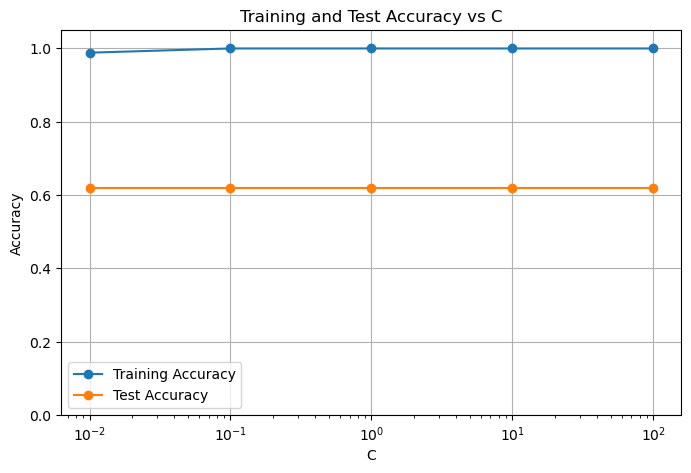

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    C_values,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    C_values,
    test_accuracies,
    marker="o",
    label="Test Accuracy"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy vs C")

plt.ylim(0, 1.05)

plt.grid(True)
plt.legend()

plt.show()

### Plot 2: actual margin

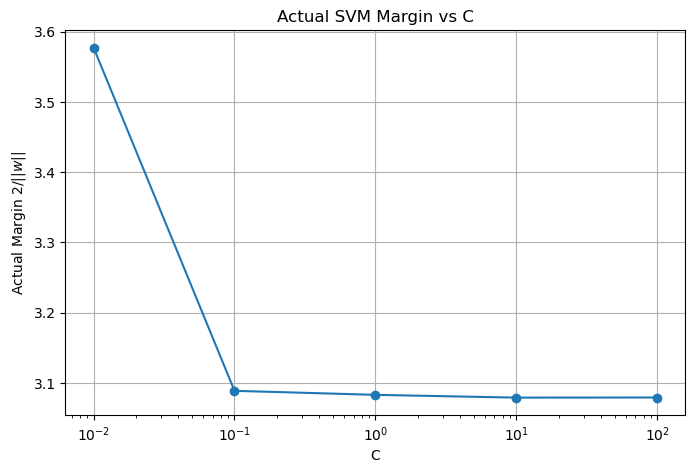

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    C_values,
    actual_margins,
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel(r"Actual Margin $2 / ||w||$")
plt.title("Actual SVM Margin vs C")

plt.grid(True)

plt.show()

### Plot 3: margin violations

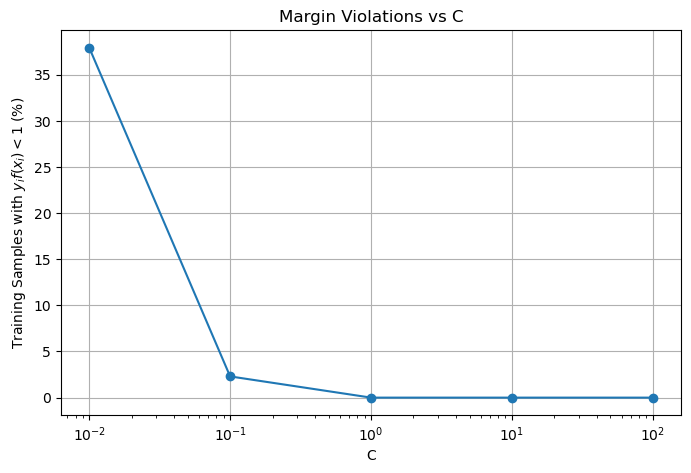

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    C_values,
    np.array(proportion_violations) * 100,
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel(
    r"Training Samples with $y_i f(x_i) < 1$ (%)"
)

plt.title("Margin Violations vs C")

plt.grid(True)

plt.show()

### Note of the current baseline at this stage
* 32 x 32, grascale, flattened, standarscaler
* probably C = 0.1 based on previous part, and the various parameters

### Phase 1: choose C using training-only cross-validation

In [85]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np


C_values = [0.01, 0.1, 1, 10, 100]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


print("=" * 75)
print("5-FOLD CROSS-VALIDATION FOR C")
print("=" * 75)

print(
    f"{'C':>8} "
    f"{'Mean Train Acc':>16} "
    f"{'Mean Val Acc':>14} "
    f"{'Val Std':>12}"
)

print("-" * 75)


for C in C_values:

    fold_train_acc = []
    fold_val_acc = []

    for train_idx, val_idx in cv.split(
        X_train_raw,
        y_train
    ):

        # --------------------------------------------
        # Split current fold
        # --------------------------------------------

        X_fold_train_raw = X_train_raw[train_idx]
        X_fold_val_raw = X_train_raw[val_idx]

        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]


        # --------------------------------------------
        # Fit scaler ONLY on current training fold
        # --------------------------------------------

        fold_scaler = StandardScaler()

        X_fold_train = fold_scaler.fit_transform(
            X_fold_train_raw
        )

        X_fold_val = fold_scaler.transform(
            X_fold_val_raw
        )


        # --------------------------------------------
        # Train custom SVM
        # --------------------------------------------

        svm = SoftMarginSVM(
            C=C,
            learning_rate=0.001,
            decay=0.001,
            max_iter=200000
        )

        svm.fit(
            X_fold_train,
            y_fold_train
        )


        # --------------------------------------------
        # Accuracy
        # --------------------------------------------

        train_pred = svm.predict(
            X_fold_train
        )

        val_pred = svm.predict(
            X_fold_val
        )

        fold_train_acc.append(
            np.mean(
                train_pred == y_fold_train
            )
        )

        fold_val_acc.append(
            np.mean(
                val_pred == y_fold_val
            )
        )


    print(
        f"{C:>8.2g} "
        f"{np.mean(fold_train_acc):>16.4f} "
        f"{np.mean(fold_val_acc):>14.4f} "
        f"{np.std(fold_val_acc):>12.4f}"
    )


print("=" * 75)

5-FOLD CROSS-VALIDATION FOR C
       C   Mean Train Acc   Mean Val Acc      Val Std
---------------------------------------------------------------------------
    0.01           0.9942         0.5725       0.1146
     0.1           1.0000         0.5725       0.1146
       1           1.0000         0.5725       0.1146
      10           1.0000         0.5725       0.1146
   1e+02           1.0000         0.5725       0.1146


### Changing the number of pixels we will use, part of preprocessing
* 16 x 16
* 32 x 32
* 64 x 64

In [86]:
IMAGE_SIZES = [
    (16, 16),
    (32, 32),
    (64, 64)
]

C_FIXED = 0.1

print("=" * 80)
print("5-FOLD CV: EFFECT OF IMAGE RESOLUTION")
print("=" * 80)

print(
    f"{'Image Size':>12} "
    f"{'Features':>10} "
    f"{'Train Acc':>12} "
    f"{'Val Acc':>12} "
    f"{'Val Std':>12}"
)

print("-" * 80)


for image_size in IMAGE_SIZES:

    # --------------------------------------------------
    # Reload images at this resolution
    # --------------------------------------------------

    face_features, face_labels, face_paths = load_class_images(
        FACE_DIR,
        FACE_LABEL,
        image_size
    )

    body_features, body_labels, body_paths = load_class_images(
        BODY_DIR,
        BODY_LABEL,
        image_size
    )

    X_resolution = np.array(
        face_features + body_features
    )

    y_resolution = np.array(
        face_labels + body_labels
    )


    # --------------------------------------------------
    # Recreate the SAME 75/25 split
    # --------------------------------------------------

    X_train_resolution, _, y_train_resolution, _ = train_test_split(
        X_resolution,
        y_resolution,
        test_size=0.25,
        random_state=42,
        stratify=y_resolution
    )


    # --------------------------------------------------
    # 5-fold CV using training data only
    # --------------------------------------------------

    fold_train_acc = []
    fold_val_acc = []

    for train_idx, val_idx in cv.split(
        X_train_resolution,
        y_train_resolution
    ):

        X_fold_train_raw = X_train_resolution[train_idx]
        X_fold_val_raw = X_train_resolution[val_idx]

        y_fold_train = y_train_resolution[train_idx]
        y_fold_val = y_train_resolution[val_idx]


        # Fit scaler only on current training fold
        fold_scaler = StandardScaler()

        X_fold_train = fold_scaler.fit_transform(
            X_fold_train_raw
        )

        X_fold_val = fold_scaler.transform(
            X_fold_val_raw
        )


        svm = SoftMarginSVM(
            C=C_FIXED,
            learning_rate=0.001,
            decay=0.001,
            max_iter=200000
        )

        svm.fit(
            X_fold_train,
            y_fold_train
        )


        fold_train_acc.append(
            np.mean(
                svm.predict(X_fold_train)
                == y_fold_train
            )
        )

        fold_val_acc.append(
            np.mean(
                svm.predict(X_fold_val)
                == y_fold_val
            )
        )


    print(
        f"{str(image_size):>12} "
        f"{X_train_resolution.shape[1]:>10d} "
        f"{np.mean(fold_train_acc):>12.4f} "
        f"{np.mean(fold_val_acc):>12.4f} "
        f"{np.std(fold_val_acc):>12.4f}"
    )


print("=" * 80)

5-FOLD CV: EFFECT OF IMAGE RESOLUTION
  Image Size   Features    Train Acc      Val Acc      Val Std
--------------------------------------------------------------------------------
    (16, 16)        256       0.9942       0.5732       0.0857
    (32, 32)       1024       1.0000       0.5725       0.1146
    (64, 64)       4096       1.0000       0.5843       0.1167


### Repeated stratified K fold for the different image sizes

In [88]:
from sklearn.model_selection import RepeatedStratifiedKFold

IMAGE_SIZES = [
    (16, 16),
    (32, 32),
    (64, 64)
]

C_FIXED = 0.1

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

print("=" * 80)
print("REPEATED 5-FOLD CV: EFFECT OF IMAGE RESOLUTION")
print("=" * 80)

print(
    f"{'Image Size':>12} "
    f"{'Features':>10} "
    f"{'Train Acc':>12} "
    f"{'Val Acc':>12} "
    f"{'Val Std':>12}"
)

print("-" * 80)


for image_size in IMAGE_SIZES:

    face_features, face_labels, _ = load_class_images(
        FACE_DIR,
        FACE_LABEL,
        image_size
    )

    body_features, body_labels, _ = load_class_images(
        BODY_DIR,
        BODY_LABEL,
        image_size
    )

    X_resolution = np.array(
        face_features + body_features
    )

    y_resolution = np.array(
        face_labels + body_labels
    )

    # Same outer train/test split as before
    X_train_resolution, _, y_train_resolution, _ = train_test_split(
        X_resolution,
        y_resolution,
        test_size=0.25,
        random_state=42,
        stratify=y_resolution
    )

    fold_train_acc = []
    fold_val_acc = []


    for train_idx, val_idx in cv.split(
        X_train_resolution,
        y_train_resolution
    ):

        X_fold_train_raw = X_train_resolution[train_idx]
        X_fold_val_raw = X_train_resolution[val_idx]

        y_fold_train = y_train_resolution[train_idx]
        y_fold_val = y_train_resolution[val_idx]

        scaler = StandardScaler()

        X_fold_train = scaler.fit_transform(
            X_fold_train_raw
        )

        X_fold_val = scaler.transform(
            X_fold_val_raw
        )

        svm = SoftMarginSVM(
            C=C_FIXED,
            learning_rate=0.001,
            decay=0.001,
            max_iter=200000
        )

        svm.fit(
            X_fold_train,
            y_fold_train
        )

        fold_train_acc.append(
            np.mean(
                svm.predict(X_fold_train)
                == y_fold_train
            )
        )

        fold_val_acc.append(
            np.mean(
                svm.predict(X_fold_val)
                == y_fold_val
            )
        )


    print(
        f"{str(image_size):>12} "
        f"{X_train_resolution.shape[1]:>10d} "
        f"{np.mean(fold_train_acc):>12.4f} "
        f"{np.mean(fold_val_acc):>12.4f} "
        f"{np.std(fold_val_acc):>12.4f}"
    )

print("=" * 80)

REPEATED 5-FOLD CV: EFFECT OF IMAGE RESOLUTION
  Image Size   Features    Train Acc      Val Acc      Val Std
--------------------------------------------------------------------------------
    (16, 16)        256       0.9954       0.5575       0.1113
    (32, 32)       1024       1.0000       0.5643       0.1079
    (64, 64)       4096       1.0000       0.5667       0.1019


### Jointly test image size and C values using repeated stratified 5-fold CV with 5 repeats, with the same train test split

In [95]:
# ============================================================
# JOINT MODEL-SELECTION EXPERIMENT
# Image resolution × C
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score
)


# ------------------------------------------------------------
# Hyperparameters to compare
# ------------------------------------------------------------

IMAGE_SIZES_JOINT = [
    (16, 16),
    (32, 32),
    (64, 64)
]

C_VALUES_JOINT = [
    0.01,
    0.1,
    1.0
]


# ------------------------------------------------------------
# Training settings
#
# Keep these identical to the previous CV experiments so that
# the results are directly comparable.
# ------------------------------------------------------------

LEARNING_RATE_JOINT = 0.001
DECAY_JOINT = 0.001
MAX_ITER_JOINT = 200000


# ------------------------------------------------------------
# Repeated stratified K-fold settings
# ------------------------------------------------------------

N_SPLITS = 5
N_REPEATS = 5
RANDOM_STATE = 42


# ------------------------------------------------------------
# Reconstruct the OUTER train/test indices once.
#
# This guarantees that every image resolution uses exactly the
# same samples for training and testing.
#
# IMPORTANT:
# The test indices will NOT be used during model selection.
# ------------------------------------------------------------

all_indices = np.arange(len(y))

train_indices_joint, test_indices_joint = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

y_train_joint = y[train_indices_joint]


print("Outer split:")
print("Training samples:", len(train_indices_joint))
print("Testing samples: ", len(test_indices_joint))


# ------------------------------------------------------------
# Construct the repeated CV splits ONCE.
#
# Every resolution and every C therefore sees exactly the same
# CV train/validation partitions.
# ------------------------------------------------------------

joint_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

cv_splits_joint = list(
    joint_cv.split(
        np.zeros(len(y_train_joint)),
        y_train_joint
    )
)

print("Number of CV folds:", len(cv_splits_joint))
print(
    "Total SVM fits:",
    len(IMAGE_SIZES_JOINT)
    * len(C_VALUES_JOINT)
    * len(cv_splits_joint)
)

Outer split:
Training samples: 87
Testing samples:  29
Number of CV folds: 25
Total SVM fits: 225


In [96]:
# ============================================================
# RUN JOINT REPEATED CROSS-VALIDATION
# ============================================================

fold_results = []
summary_results = []

experiment_start = time.time()

total_configurations = (
    len(IMAGE_SIZES_JOINT)
    * len(C_VALUES_JOINT)
)

configuration_number = 0


print("=" * 90)
print("JOINT REPEATED 5-FOLD CV: IMAGE RESOLUTION × C")
print("=" * 90)


# ============================================================
# Loop over image resolutions
# ============================================================

for image_size in IMAGE_SIZES_JOINT:

    print(
        f"\nLoading images at resolution {image_size}...",
        flush=True
    )


    # --------------------------------------------------------
    # Reload all images using the selected resolution
    # --------------------------------------------------------

    face_features, face_labels, _ = load_class_images(
        FACE_DIR,
        FACE_LABEL,
        image_size
    )

    body_features, body_labels, _ = load_class_images(
        BODY_DIR,
        BODY_LABEL,
        image_size
    )


    X_resolution = np.array(
        face_features + body_features
    )

    y_resolution = np.array(
        face_labels + body_labels
    )


    # --------------------------------------------------------
    # Sanity check:
    # changing image resolution must not change sample order
    # or labels.
    # --------------------------------------------------------

    assert np.array_equal(
        y_resolution,
        y
    ), (
        "Sample ordering changed between image resolutions."
    )


    # --------------------------------------------------------
    # Apply the SAME outer training indices
    #
    # Test samples remain completely untouched.
    # --------------------------------------------------------

    X_train_resolution_raw = (
        X_resolution[train_indices_joint]
    )

    y_train_resolution = (
        y_resolution[train_indices_joint]
    )

    n_features = X_train_resolution_raw.shape[1]


    # ========================================================
    # Loop over C values
    # ========================================================

    for C in C_VALUES_JOINT:

        configuration_number += 1

        config_start = time.time()

        print(
            f"\n[{configuration_number}/{total_configurations}] "
            f"Image size = {image_size}, "
            f"C = {C}",
            flush=True
        )


        # ----------------------------------------------------
        # Store results for the 25 folds in this configuration
        # ----------------------------------------------------

        config_train_acc = []
        config_val_acc = []

        config_balanced_acc = []

        config_body_recall = []
        config_face_recall = []

        config_margin = []
        config_violation_prop = []


        # ====================================================
        # Repeated stratified CV
        # ====================================================

        for fold_number, (train_idx, val_idx) in enumerate(
            cv_splits_joint,
            start=1
        ):

            # ------------------------------------------------
            # Current fold
            # ------------------------------------------------

            X_fold_train_raw = (
                X_train_resolution_raw[train_idx]
            )

            X_fold_val_raw = (
                X_train_resolution_raw[val_idx]
            )

            y_fold_train = (
                y_train_resolution[train_idx]
            )

            y_fold_val = (
                y_train_resolution[val_idx]
            )


            # ------------------------------------------------
            # Standardize using ONLY the current training fold
            #
            # Prevents validation-data leakage.
            # ------------------------------------------------

            fold_scaler = StandardScaler()

            X_fold_train = fold_scaler.fit_transform(
                X_fold_train_raw
            )

            X_fold_val = fold_scaler.transform(
                X_fold_val_raw
            )


            # ------------------------------------------------
            # Train custom soft-margin SVM
            # ------------------------------------------------

            svm_joint = SoftMarginSVM(
                C=C,
                learning_rate=LEARNING_RATE_JOINT,
                decay=DECAY_JOINT,
                max_iter=MAX_ITER_JOINT
            )

            svm_joint.fit(
                X_fold_train,
                y_fold_train
            )


            # ------------------------------------------------
            # Predictions
            # ------------------------------------------------

            train_pred = svm_joint.predict(
                X_fold_train
            )

            val_pred = svm_joint.predict(
                X_fold_val
            )


            # ------------------------------------------------
            # Accuracy
            # ------------------------------------------------

            train_acc = accuracy_score(
                y_fold_train,
                train_pred
            )

            val_acc = accuracy_score(
                y_fold_val,
                val_pred
            )


            # ------------------------------------------------
            # Balanced accuracy
            #
            # Useful because cougar-face and cougar-body
            # sample counts are not exactly equal.
            # ------------------------------------------------

            balanced_acc = balanced_accuracy_score(
                y_fold_val,
                val_pred
            )


            # ------------------------------------------------
            # Recall for each individual class
            # ------------------------------------------------

            body_recall = recall_score(
                y_fold_val,
                val_pred,
                pos_label=BODY_LABEL,
                zero_division=0
            )

            face_recall = recall_score(
                y_fold_val,
                val_pred,
                pos_label=FACE_LABEL,
                zero_division=0
            )


            # ------------------------------------------------
            # Actual geometric margin
            #
            # margin = 2 / ||w||
            # ------------------------------------------------

            w_norm = np.linalg.norm(
                svm_joint.w
            )

            if w_norm > 0:
                actual_margin = 2 / w_norm
            else:
                actual_margin = np.inf


            # ------------------------------------------------
            # Proportion of training samples violating margin
            #
            # y_i f(x_i) < 1
            # ------------------------------------------------

            train_scores = svm_joint.decision_function(
                X_fold_train
            )

            train_margins = (
                y_fold_train * train_scores
            )

            violation_prop = np.mean(
                train_margins < 1
            )


            # ------------------------------------------------
            # Store this fold
            # ------------------------------------------------

            config_train_acc.append(
                train_acc
            )

            config_val_acc.append(
                val_acc
            )

            config_balanced_acc.append(
                balanced_acc
            )

            config_body_recall.append(
                body_recall
            )

            config_face_recall.append(
                face_recall
            )

            config_margin.append(
                actual_margin
            )

            config_violation_prop.append(
                violation_prop
            )


            fold_results.append({
                "Image Size": str(image_size),
                "Features": n_features,
                "C": C,
                "Fold": fold_number,

                "Train Accuracy": train_acc,
                "Validation Accuracy": val_acc,
                "Balanced Accuracy": balanced_acc,

                "Body Recall": body_recall,
                "Face Recall": face_recall,

                "Actual Margin": actual_margin,
                "Violation Proportion": violation_prop
            })


            # ------------------------------------------------
            # Small progress message every five folds
            # ------------------------------------------------

            if fold_number % 5 == 0:

                print(
                    f"    completed "
                    f"{fold_number:>2}/{len(cv_splits_joint)} folds",
                    flush=True
                )


        # ====================================================
        # Summarize current configuration
        # ====================================================

        config_summary = {

            "Image Size": str(image_size),
            "Features": n_features,
            "C": C,

            "Mean Train Accuracy":
                np.mean(config_train_acc),

            "Mean Validation Accuracy":
                np.mean(config_val_acc),

            "Validation Accuracy Std":
                np.std(config_val_acc),

            "Mean Balanced Accuracy":
                np.mean(config_balanced_acc),

            "Balanced Accuracy Std":
                np.std(config_balanced_acc),

            "Mean Body Recall":
                np.mean(config_body_recall),

            "Mean Face Recall":
                np.mean(config_face_recall),

            "Mean Actual Margin":
                np.mean(config_margin),

            "Mean Violation Proportion":
                np.mean(config_violation_prop)
        }


        summary_results.append(
            config_summary
        )


        # ----------------------------------------------------
        # CHECKPOINT RESULTS
        #
        # This means that if the notebook is interrupted,
        # results from completed configurations are not lost.
        # ----------------------------------------------------

        fold_results_df = pd.DataFrame(
            fold_results
        )

        summary_results_df = pd.DataFrame(
            summary_results
        )


        fold_results_df.to_csv(
            "linear_svm_joint_cv_fold_results.csv",
            index=False
        )

        summary_results_df.to_csv(
            "linear_svm_joint_cv_summary.csv",
            index=False
        )


        # ----------------------------------------------------
        # Progress report
        # ----------------------------------------------------

        config_elapsed = (
            time.time() - config_start
        )

        total_elapsed = (
            time.time() - experiment_start
        )


        print(
            f"    Mean validation accuracy: "
            f"{config_summary['Mean Validation Accuracy']:.4f}"
        )

        print(
            f"    Mean balanced accuracy:   "
            f"{config_summary['Mean Balanced Accuracy']:.4f}"
        )

        print(
            f"    Configuration time:       "
            f"{config_elapsed / 60:.2f} min"
        )

        print(
            f"    Total elapsed:            "
            f"{total_elapsed / 60:.2f} min",
            flush=True
        )


# ============================================================
# Finished
# ============================================================

total_elapsed = (
    time.time() - experiment_start
)

print("\n" + "=" * 90)
print("JOINT CROSS-VALIDATION COMPLETE")
print("=" * 90)

print(
    f"Total runtime: "
    f"{total_elapsed / 60:.2f} minutes"
)

print(
    "\nSaved:"
    "\n  linear_svm_joint_cv_fold_results.csv"
    "\n  linear_svm_joint_cv_summary.csv"
)

JOINT REPEATED 5-FOLD CV: IMAGE RESOLUTION × C

Loading images at resolution (16, 16)...

[1/9] Image size = (16, 16), C = 0.01
    completed  5/25 folds
    completed 10/25 folds
    completed 15/25 folds
    completed 20/25 folds
    completed 25/25 folds
    Mean validation accuracy: 0.5970
    Mean balanced accuracy:   0.5721
    Configuration time:       20.66 min
    Total elapsed:            20.66 min

[2/9] Image size = (16, 16), C = 0.1
    completed  5/25 folds
    completed 10/25 folds
    completed 15/25 folds
    completed 20/25 folds
    completed 25/25 folds
    Mean validation accuracy: 0.5575
    Mean balanced accuracy:   0.5423
    Configuration time:       14.41 min
    Total elapsed:            35.08 min

[3/9] Image size = (16, 16), C = 1.0
    completed  5/25 folds
    completed 10/25 folds
    completed 15/25 folds
    completed 20/25 folds
    completed 25/25 folds
    Mean validation accuracy: 0.5578
    Mean balanced accuracy:   0.5465
    Configuration time: 

In [101]:
# ============================================================
# DISPLAY JOINT CV RESULTS
# ============================================================

summary_results_df = pd.read_csv(
    "linear_svm_joint_cv_summary.csv"
)


display_columns = [
    "Image Size",
    "Features",
    "C",
    "Mean Train Accuracy",
    "Mean Validation Accuracy",
    "Validation Accuracy Std",
    "Mean Balanced Accuracy",
    "Mean Body Recall",
    "Mean Face Recall",
    "Mean Actual Margin",
    "Mean Violation Proportion"
]


# Sort only for easier inspection.
#
# We are NOT declaring the first row to automatically be
# the optimal model.
joint_cv_display = (
    summary_results_df[display_columns]
    .sort_values(
        by=[
            "Mean Validation Accuracy",
            "Mean Balanced Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)


joint_cv_display

,Image Size,Features,C,Mean Train Accuracy,Mean Validation Accuracy,Validation Accuracy Std,Mean Balanced Accuracy,Mean Body Recall,Mean Face Recall,Mean Actual Margin,Mean Violation Proportion
0,"(16, 16)",256,0.0100,0.8925,0.5970,0.0843,0.5721,0.4457,0.6985,4.1527,0.7100
1,"(64, 64)",4096,0.0100,1.0000,0.5667,0.1019,0.5546,0.4914,0.6178,8.2216,0.0282
2,"(64, 64)",4096,0.1000,1.0000,0.5667,0.1019,0.5546,0.4914,0.6178,8.2048,0.0092
3,"(64, 64)",4096,1.0000,1.0000,0.5667,0.1059,0.5546,0.4914,0.6178,8.1917,0.0017
4,"(32, 32)",1024,0.1000,1.0000,0.5643,0.1079,0.5566,0.5143,0.5989,3.6904,0.0155
5,"(32, 32)",1024,1.0000,1.0000,0.5643,0.1079,0.5566,0.5143,0.5989,3.6835,0.0023
6,"(32, 32)",1024,0.0100,0.9954,0.5641,0.1161,0.5507,0.4800,0.6215,4.1215,0.3409
7,"(16, 16)",256,1.0000,1.0000,0.5578,0.0983,0.5465,0.4857,0.6073,1.4269,0.0149
8,"(16, 16)",256,0.1000,0.9954,0.5575,0.1113,0.5423,0.4629,0.6218,1.5453,0.1920


### Diagnostic SVM class. same as softmargin SVM, just records more diagnostics

In [97]:
# ============================================================
# DIAGNOSTIC VERSION OF SOFT-MARGIN SVM
#
# Same optimization method as the original implementation,
# but records additional convergence information.
# ============================================================

import numpy as np


class DiagnosticSoftMarginSVM:

    def __init__(
        self,
        C=1.0,
        learning_rate=0.001,
        decay=0.001,
        max_iter=50000,
        max_grad_norm=100.0
    ):
        self.C = C
        self.learning_rate = learning_rate
        self.decay = decay
        self.max_iter = max_iter
        self.max_grad_norm = max_grad_norm

        self.w = None
        self.b = None

        # Diagnostic quantities
        self.loss_history = []

        self.best_loss = None
        self.best_iter = None

        self.first_zero_violation_iter = None

        self.n_clipped_steps = 0
        self.clip_fraction = 0.0
        self.max_observed_grad_norm = 0.0

        self.end_loss_before_restore = None


    def _loss(self, X, y):

        scores = X @ self.w + self.b
        margins = y * scores

        hinge_loss = np.maximum(
            0,
            1 - margins
        )

        return (
            0.5 * np.dot(self.w, self.w)
            + self.C * np.sum(hinge_loss)
        )


    def fit(self, X, y):

        n_samples, n_features = X.shape

        if not np.all(
            np.isin(
                np.unique(y),
                [-1, 1]
            )
        ):
            raise ValueError(
                "SVM labels must be -1 or +1."
            )


        # ----------------------------------------------------
        # Initialize parameters
        # ----------------------------------------------------

        self.w = np.zeros(n_features)
        self.b = 0.0

        self.loss_history = []

        self.n_clipped_steps = 0
        self.max_observed_grad_norm = 0.0

        self.first_zero_violation_iter = None


        # ----------------------------------------------------
        # Track best parameters
        # ----------------------------------------------------

        best_loss = np.inf

        best_w = self.w.copy()
        best_b = self.b

        best_iter = 0


        # ====================================================
        # Full-batch subgradient descent
        # ====================================================

        for iteration in range(self.max_iter):

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            scores = X @ self.w + self.b

            margins = y * scores

            violations = margins < 1


            # ------------------------------------------------
            # First iteration with no margin violations
            # ------------------------------------------------

            if (
                self.first_zero_violation_iter is None
                and not np.any(violations)
            ):
                self.first_zero_violation_iter = iteration


            # ------------------------------------------------
            # Current objective value
            #
            # We calculate it using margins already computed
            # above instead of performing another X @ w.
            # ------------------------------------------------

            hinge_loss = np.maximum(
                0,
                1 - margins
            )

            current_loss = (
                0.5 * np.dot(self.w, self.w)
                + self.C * np.sum(hinge_loss)
            )

            self.loss_history.append(
                current_loss
            )


            # ------------------------------------------------
            # Store best solution seen so far
            # ------------------------------------------------

            if current_loss < best_loss:

                best_loss = current_loss

                best_w = self.w.copy()
                best_b = self.b

                best_iter = iteration


            # ------------------------------------------------
            # Full-batch subgradient
            # ------------------------------------------------

            dw = self.w.copy()
            db = 0.0


            if np.any(violations):

                dw -= self.C * (
                    X[violations].T
                    @ y[violations]
                )

                db = -self.C * np.sum(
                    y[violations]
                )


            # ------------------------------------------------
            # Gradient norm
            # ------------------------------------------------

            grad_norm = np.sqrt(
                np.dot(dw, dw)
                + db ** 2
            )

            self.max_observed_grad_norm = max(
                self.max_observed_grad_norm,
                grad_norm
            )


            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            if (
                self.max_grad_norm is not None
                and grad_norm > self.max_grad_norm
            ):

                scale = (
                    self.max_grad_norm
                    / grad_norm
                )

                dw *= scale
                db *= scale

                self.n_clipped_steps += 1


            # ------------------------------------------------
            # Inverse-time learning-rate decay
            #
            # eta_t = eta_0 / (1 + alpha * t)
            # ------------------------------------------------

            eta = (
                self.learning_rate
                / (
                    1
                    + self.decay * iteration
                )
            )


            # ------------------------------------------------
            # Parameter update
            # ------------------------------------------------

            self.w -= eta * dw
            self.b -= eta * db


        # ----------------------------------------------------
        # Loss at the actual final iteration BEFORE restoring
        # the best-observed parameters.
        # ----------------------------------------------------

        self.end_loss_before_restore = (
            self._loss(X, y)
        )


        # ----------------------------------------------------
        # Restore lowest-loss parameters
        # ----------------------------------------------------

        self.w = best_w
        self.b = best_b

        self.best_loss = best_loss
        self.best_iter = best_iter

        self.clip_fraction = (
            self.n_clipped_steps
            / self.max_iter
        )


        return self


    def decision_function(self, X):

        return X @ self.w + self.b


    def predict(self, X):

        scores = self.decision_function(X)

        return np.where(
            scores >= 0,
            1,
            -1
        )

### diagnostic experiment to test initial learning rate, decay alpha.
* Fixed: image size of 32x32, C = 0.1, full-batch subgradient descent

In [98]:
# ============================================================
# OPTIMIZER DIAGNOSTIC EXPERIMENT
#
# Fixed:
#   Image size = 32 x 32
#   C          = 0.1
#   Optimizer  = full-batch subgradient descent
#
# Tested:
#   initial learning rate
#   decay alpha
# ============================================================

import os
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# Fixed model settings
# ------------------------------------------------------------

OPT_IMAGE_SIZE = (32, 32)
OPT_C = 0.1

MAX_ITER_DIAGNOSTIC = 50000
MAX_GRAD_NORM_DIAGNOSTIC = 100.0


# ------------------------------------------------------------
# Optimizer settings to compare
# ------------------------------------------------------------

LEARNING_RATES = [
    0.0001,
    0.0005,
    0.001,
    0.005
]

DECAY_VALUES = [
    0.0,
    0.0001,
    0.001,
    0.01
]


# ------------------------------------------------------------
# Load 32 x 32 representation explicitly
#
# This avoids depending on what IMAGE_SIZE may currently be
# elsewhere in the notebook.
# ------------------------------------------------------------

face_features_opt, face_labels_opt, _ = load_class_images(
    FACE_DIR,
    FACE_LABEL,
    OPT_IMAGE_SIZE
)

body_features_opt, body_labels_opt, _ = load_class_images(
    BODY_DIR,
    BODY_LABEL,
    OPT_IMAGE_SIZE
)


X_opt = np.array(
    face_features_opt
    + body_features_opt
)

y_opt = np.array(
    face_labels_opt
    + body_labels_opt
)


# ------------------------------------------------------------
# Recreate SAME 75/25 outer split
#
# The test portion is deliberately not used below.
# ------------------------------------------------------------

all_indices_opt = np.arange(
    len(y_opt)
)

train_indices_opt, test_indices_opt = train_test_split(
    all_indices_opt,
    test_size=0.25,
    random_state=42,
    stratify=y_opt
)


X_opt_train_raw = (
    X_opt[train_indices_opt]
)

y_opt_train = (
    y_opt[train_indices_opt]
)


# ------------------------------------------------------------
# Standardization fitted ONLY to the training set
# ------------------------------------------------------------

optimizer_scaler = StandardScaler()

X_opt_train = optimizer_scaler.fit_transform(
    X_opt_train_raw
)


print("Optimizer diagnostic dataset")
print("----------------------------")
print("Training samples:", len(y_opt_train))
print("Feature dimension:", X_opt_train.shape[1])
print("Test samples used during diagnostics: 0")


# ============================================================
# Helper: best loss obtained within first N iterations
# ============================================================

def best_loss_by_iteration(
    loss_history,
    n_iterations
):

    n = min(
        n_iterations,
        len(loss_history)
    )

    return np.min(
        loss_history[:n]
    )


# ============================================================
# Helper: first iteration whose loss gets sufficiently close
# to the final best observed loss
# ============================================================

def first_near_best_iteration(
    loss_history,
    best_loss,
    relative_tolerance
):

    loss_history = np.asarray(
        loss_history
    )

    threshold = (
        best_loss
        * (1 + relative_tolerance)
    )

    candidates = np.where(
        loss_history <= threshold
    )[0]

    if len(candidates) == 0:
        return np.nan

    return int(
        candidates[0]
    )


# ============================================================
# Run experiment
# ============================================================

optimizer_results = []

# Only store sampled loss curves to keep the file small.
loss_curve_records = []

total_configs = (
    len(LEARNING_RATES)
    * len(DECAY_VALUES)
)

config_number = 0

experiment_start = time.time()


print("\n" + "=" * 95)
print("OPTIMIZER DIAGNOSTICS: LEARNING RATE × DECAY")
print("=" * 95)


for learning_rate in LEARNING_RATES:

    for decay in DECAY_VALUES:

        config_number += 1

        config_start = time.time()


        print(
            f"\n[{config_number}/{total_configs}] "
            f"learning_rate={learning_rate:g}, "
            f"decay={decay:g}",
            flush=True
        )


        # ----------------------------------------------------
        # Train diagnostic SVM
        # ----------------------------------------------------

        svm_diag = DiagnosticSoftMarginSVM(
            C=OPT_C,
            learning_rate=learning_rate,
            decay=decay,
            max_iter=MAX_ITER_DIAGNOSTIC,
            max_grad_norm=MAX_GRAD_NORM_DIAGNOSTIC
        )

        svm_diag.fit(
            X_opt_train,
            y_opt_train
        )


        # ----------------------------------------------------
        # Evaluate best-observed parameters
        # ----------------------------------------------------

        train_pred = svm_diag.predict(
            X_opt_train
        )

        train_accuracy = np.mean(
            train_pred
            == y_opt_train
        )


        scores = svm_diag.decision_function(
            X_opt_train
        )

        margins = (
            y_opt_train
            * scores
        )


        n_violations = np.sum(
            margins < 1
        )

        violation_proportion = np.mean(
            margins < 1
        )


        w_norm = np.linalg.norm(
            svm_diag.w
        )

        actual_margin = (
            2 / w_norm
            if w_norm > 0
            else np.inf
        )


        # ----------------------------------------------------
        # Convergence diagnostics
        # ----------------------------------------------------

        loss_history = np.asarray(
            svm_diag.loss_history
        )


        best_1k = best_loss_by_iteration(
            loss_history,
            1000
        )

        best_5k = best_loss_by_iteration(
            loss_history,
            5000
        )

        best_10k = best_loss_by_iteration(
            loss_history,
            10000
        )

        best_25k = best_loss_by_iteration(
            loss_history,
            25000
        )

        best_50k = best_loss_by_iteration(
            loss_history,
            50000
        )


        # How much did the best objective improve
        # between iteration 25k and 50k?
        improvement_25k_to_50k = (
            (
                best_25k
                - best_50k
            )
            / max(
                abs(best_50k),
                1e-12
            )
        )


        first_within_1pct = (
            first_near_best_iteration(
                loss_history,
                svm_diag.best_loss,
                relative_tolerance=0.01
            )
        )

        first_within_0_1pct = (
            first_near_best_iteration(
                loss_history,
                svm_diag.best_loss,
                relative_tolerance=0.001
            )
        )


        # ----------------------------------------------------
        # Did best loss occur suspiciously close to our
        # iteration limit?
        # ----------------------------------------------------

        hit_iteration_boundary = (
            svm_diag.best_iter
            >= 0.90
            * MAX_ITER_DIAGNOSTIC
        )


        # ----------------------------------------------------
        # Current learning rate at best iteration
        # ----------------------------------------------------

        eta_at_best = (
            learning_rate
            / (
                1
                + decay
                * svm_diag.best_iter
            )
        )


        result = {

            "Learning Rate":
                learning_rate,

            "Decay":
                decay,

            "Best Loss":
                svm_diag.best_loss,

            "Best Iteration":
                svm_diag.best_iter,

            "Eta at Best":
                eta_at_best,

            "End Loss Before Restore":
                svm_diag.end_loss_before_restore,

            "Best Loss @ 1k":
                best_1k,

            "Best Loss @ 5k":
                best_5k,

            "Best Loss @ 10k":
                best_10k,

            "Best Loss @ 25k":
                best_25k,

            "Best Loss @ 50k":
                best_50k,

            "25k->50k Improvement":
                improvement_25k_to_50k,

            "Within 1% Best Iter":
                first_within_1pct,

            "Within 0.1% Best Iter":
                first_within_0_1pct,

            "Hit Iteration Boundary":
                hit_iteration_boundary,

            "Train Accuracy":
                train_accuracy,

            "||w||":
                w_norm,

            "Actual Margin":
                actual_margin,

            "Violations":
                int(n_violations),

            "Violation Proportion":
                violation_proportion,

            "First Zero-Violation Iter":
                svm_diag.first_zero_violation_iter,

            "Clipped Steps":
                svm_diag.n_clipped_steps,

            "Clip Fraction":
                svm_diag.clip_fraction,

            "Max Observed Grad Norm":
                svm_diag.max_observed_grad_norm
        }


        optimizer_results.append(
            result
        )


        # ----------------------------------------------------
        # Save a sampled convergence curve.
        #
        # Every 100 iterations is enough for later plotting.
        # Also explicitly save the best iteration.
        # ----------------------------------------------------

        sample_iterations = set(
            range(
                0,
                len(loss_history),
                100
            )
        )

        sample_iterations.add(
            svm_diag.best_iter
        )

        sample_iterations.add(
            len(loss_history) - 1
        )


        for iteration in sorted(
            sample_iterations
        ):

            eta_here = (
                learning_rate
                / (
                    1
                    + decay
                    * iteration
                )
            )

            loss_curve_records.append({

                "Learning Rate":
                    learning_rate,

                "Decay":
                    decay,

                "Iteration":
                    iteration,

                "Learning Rate at Iteration":
                    eta_here,

                "Loss":
                    loss_history[iteration]
            })


        # ----------------------------------------------------
        # CHECKPOINT
        #
        # Results from completed configurations are written
        # after every run.
        # ----------------------------------------------------

        optimizer_results_df = pd.DataFrame(
            optimizer_results
        )

        optimizer_loss_curves_df = pd.DataFrame(
            loss_curve_records
        )


        optimizer_results_df.to_csv(
            "optimizer_diagnostic_summary.csv",
            index=False
        )

        optimizer_loss_curves_df.to_csv(
            "optimizer_diagnostic_loss_curves.csv",
            index=False
        )


        # ----------------------------------------------------
        # Progress information
        # ----------------------------------------------------

        elapsed = (
            time.time()
            - config_start
        )

        print(
            f"    best loss:             "
            f"{svm_diag.best_loss:.6f}"
        )

        print(
            f"    best iteration:        "
            f"{svm_diag.best_iter}"
        )

        print(
            f"    training accuracy:     "
            f"{train_accuracy:.4f}"
        )

        print(
            f"    clipping frequency:    "
            f"{100 * svm_diag.clip_fraction:.3f}%"
        )

        print(
            f"    25k -> 50k improvement:"
            f" {100 * improvement_25k_to_50k:.4f}%"
        )

        print(
            f"    runtime:               "
            f"{elapsed / 60:.2f} min",
            flush=True
        )


# ============================================================
# Finished
# ============================================================

total_elapsed = (
    time.time()
    - experiment_start
)

print("\n" + "=" * 95)
print("OPTIMIZER DIAGNOSTICS COMPLETE")
print("=" * 95)

print(
    f"Total runtime: "
    f"{total_elapsed / 60:.2f} minutes"
)

print(
    "\nSaved:"
    "\n  optimizer_diagnostic_summary.csv"
    "\n  optimizer_diagnostic_loss_curves.csv"
)

Optimizer diagnostic dataset
----------------------------
Training samples: 87
Feature dimension: 1024
Test samples used during diagnostics: 0

OPTIMIZER DIAGNOSTICS: LEARNING RATE × DECAY

[1/16] learning_rate=0.0001, decay=0
    best loss:             0.214421
    best iteration:        32609
    training accuracy:     1.0000
    clipping frequency:    0.000%
    25k -> 50k improvement: 0.0731%
    runtime:               0.37 min

[2/16] learning_rate=0.0001, decay=0.0001
    best loss:             0.210621
    best iteration:        49358
    training accuracy:     1.0000
    clipping frequency:    0.000%
    25k -> 50k improvement: 0.5658%
    runtime:               0.32 min

[3/16] learning_rate=0.0001, decay=0.001
    best loss:             0.215526
    best iteration:        49921
    training accuracy:     1.0000
    clipping frequency:    0.000%
    25k -> 50k improvement: 1.4695%
    runtime:               0.37 min

[4/16] learning_rate=0.0001, decay=0.01
    best loss:      

### Display optimizer diagnostic results (send to chat)

In [99]:
# ============================================================
# DISPLAY OPTIMIZER DIAGNOSTIC RESULTS
# ============================================================

import pandas as pd


optimizer_results_df = pd.read_csv(
    "optimizer_diagnostic_summary.csv"
)


display_columns = [

    "Learning Rate",
    "Decay",

    "Best Loss",
    "Best Iteration",

    "Best Loss @ 5k",
    "Best Loss @ 10k",
    "Best Loss @ 25k",
    "Best Loss @ 50k",

    "25k->50k Improvement",

    "Within 0.1% Best Iter",
    "Hit Iteration Boundary",

    "Train Accuracy",

    "Actual Margin",
    "Violations",

    "Clip Fraction",
    "Max Observed Grad Norm"
]


optimizer_display = (
    optimizer_results_df[display_columns]
    .sort_values(
        by="Best Loss",
        ascending=True
    )
    .reset_index(drop=True)
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6f}"
)


optimizer_display

,Learning Rate,Decay,Best Loss,Best Iteration,Best Loss @ 5k,Best Loss @ 10k,Best Loss @ 25k,Best Loss @ 50k,25k->50k Improvement,Within 0.1% Best Iter,Hit Iteration Boundary,Train Accuracy,Actual Margin,Violations,Clip Fraction,Max Observed Grad Norm
0,0.005000,0.010000,0.210006,49813,0.215949,0.212419,0.210615,0.210006,0.002900,37077,True,1.000000,3.086028,1,0.000000,72.408797
1,0.000500,0.001000,0.210160,49296,0.215471,0.212978,0.210895,0.210160,0.003496,39878,True,1.000000,3.084899,1,0.000000,61.365253
2,0.001000,0.001000,0.210364,49756,0.219623,0.213953,0.211371,0.210364,0.004783,42226,True,1.000000,3.083400,1,0.000000,61.485402
3,0.000100,0.000100,0.210621,49358,0.218752,0.214418,0.211812,0.210621,0.005658,43048,True,1.000000,3.081527,1,0.000000,61.365188
4,0.001000,0.010000,0.213543,49987,0.218702,0.216420,0.214591,0.213543,0.004912,42987,True,1.000000,3.060367,1,0.000000,58.564780
5,0.000500,0.000100,0.213869,46326,0.227939,0.222718,0.216834,0.213869,0.013866,46321,True,1.000000,3.058082,1,0.000000,63.897167
6,0.005000,0.001000,0.214396,49539,0.259706,0.234349,0.219899,0.214396,0.025670,49534,True,1.000000,3.054491,2,0.000000,74.124249
7,0.000100,0.000000,0.214421,32609,0.218837,0.215938,0.214577,0.214421,0.000731,24821,False,1.000000,3.054118,1,0.000000,61.929570
8,0.000100,0.001000,0.215526,49921,0.260916,0.241588,0.218694,0.215526,0.014695,44473,True,1.000000,3.046250,1,0.000000,57.301207
9,0.001000,0.000100,0.217981,49945,0.248627,0.238190,0.224417,0.217981,0.029524,49942,True,1.000000,3.029099,1,0.000000,69.409164


### Send this to chat too

In [100]:
# ============================================================
# CONVERGENCE / MAX_ITER SUMMARY
# ============================================================

convergence_columns = [

    "Learning Rate",
    "Decay",

    "Best Loss @ 1k",
    "Best Loss @ 5k",
    "Best Loss @ 10k",
    "Best Loss @ 25k",
    "Best Loss @ 50k",

    "Best Iteration",
    "Within 1% Best Iter",
    "Within 0.1% Best Iter",

    "25k->50k Improvement",
    "Hit Iteration Boundary"
]


convergence_display = (
    optimizer_results_df[convergence_columns]
    .sort_values(
        by="Best Loss @ 50k",
        ascending=True
    )
    .reset_index(drop=True)
)


convergence_display

,Learning Rate,Decay,Best Loss @ 1k,Best Loss @ 5k,Best Loss @ 10k,Best Loss @ 25k,Best Loss @ 50k,Best Iteration,Within 1% Best Iter,Within 0.1% Best Iter,25k->50k Improvement,Hit Iteration Boundary
0,0.005000,0.010000,0.245097,0.215949,0.212419,0.210615,0.210006,49813,11935,37077,0.002900,True
1,0.000500,0.001000,0.234944,0.215471,0.212978,0.210895,0.210160,49296,12672,39878,0.003496,True
2,0.001000,0.001000,0.245643,0.219623,0.213953,0.211371,0.210364,49756,17488,42226,0.004783,True
3,0.000100,0.000100,0.634504,0.218752,0.214418,0.211812,0.210621,49358,16173,43048,0.005658,True
4,0.001000,0.010000,0.249427,0.218702,0.216420,0.214591,0.213543,49987,13905,42987,0.004912,True
5,0.000500,0.000100,0.243791,0.227939,0.222718,0.216834,0.213869,46326,28947,46321,0.013866,True
6,0.005000,0.001000,0.403322,0.259706,0.234349,0.219899,0.214396,49539,36059,49534,0.025670,True
7,0.000100,0.000000,0.592631,0.218837,0.215938,0.214577,0.214421,32609,8379,24821,0.000731,False
8,0.000100,0.001000,0.983792,0.260916,0.241588,0.218694,0.215526,49921,26116,44473,0.014695,True
9,0.001000,0.000100,0.268212,0.248627,0.238190,0.224417,0.217981,49945,39781,49942,0.029524,True


### Load and verify the final three candidates

In [1]:
# ============================================================
# PAIRED-FOLD COMPARISON OF TOP LINEAR SVM CANDIDATES
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Load fold-level results from the joint repeated CV
# ------------------------------------------------------------

fold_df = pd.read_csv(
    "linear_svm_joint_cv_fold_results.csv"
)


# ------------------------------------------------------------
# Define the three candidate configurations
# ------------------------------------------------------------

candidates = {
    "A: 16x16, C=0.01": {
        "Image Size": "(16, 16)",
        "C": 0.01
    },

    "B: 32x32, C=0.1": {
        "Image Size": "(32, 32)",
        "C": 0.1
    },

    "C: 64x64, C=0.1": {
        "Image Size": "(64, 64)",
        "C": 0.1
    }
}


# ------------------------------------------------------------
# Extract candidate results
# ------------------------------------------------------------

candidate_frames = []


for candidate_name, settings in candidates.items():

    temp = fold_df[
        (fold_df["Image Size"] == settings["Image Size"])
        &
        np.isclose(
            fold_df["C"],
            settings["C"]
        )
    ].copy()


    temp["Candidate"] = candidate_name


    print(
        f"{candidate_name}: "
        f"{len(temp)} fold results found"
    )


    candidate_frames.append(
        temp
    )


candidate_df = pd.concat(
    candidate_frames,
    ignore_index=True
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

expected_folds = 25

for candidate_name in candidates:

    n = np.sum(
        candidate_df["Candidate"]
        == candidate_name
    )

    assert n == expected_folds, (
        f"{candidate_name} has {n} folds, "
        f"expected {expected_folds}."
    )


print("\nAll candidates contain 25 folds.")
print("Paired comparison can proceed.")

A: 16x16, C=0.01: 25 fold results found
B: 32x32, C=0.1: 25 fold results found
C: 64x64, C=0.1: 25 fold results found

All candidates contain 25 folds.
Paired comparison can proceed.


### Construct the final paired fold table

In [2]:
# ============================================================
# CREATE MATCHED FOLD TABLES
# ============================================================

# ------------------------------------------------------------
# Validation accuracy
# ------------------------------------------------------------

accuracy_pivot = candidate_df.pivot(
    index="Fold",
    columns="Candidate",
    values="Validation Accuracy"
).sort_index()


# ------------------------------------------------------------
# Balanced accuracy
# ------------------------------------------------------------

balanced_pivot = candidate_df.pivot(
    index="Fold",
    columns="Candidate",
    values="Balanced Accuracy"
).sort_index()


# ------------------------------------------------------------
# Verify that no folds are missing
# ------------------------------------------------------------

assert not accuracy_pivot.isna().any().any(), (
    "Missing validation accuracy for at least one paired fold."
)

assert not balanced_pivot.isna().any().any(), (
    "Missing balanced accuracy for at least one paired fold."
)


print("Validation Accuracy by matched fold:")
display(accuracy_pivot)

print("\nBalanced Accuracy by matched fold:")
display(balanced_pivot)

Validation Accuracy by matched fold:


Candidate,"A: 16x16, C=0.01","B: 32x32, C=0.1","C: 64x64, C=0.1"
Fold,,,
1,0.666667,0.611111,0.555556
2,0.666667,0.722222,0.777778
3,0.588235,0.470588,0.470588
4,0.529412,0.411765,0.470588
5,0.529412,0.647059,0.647059
6,0.666667,0.722222,0.722222
7,0.444444,0.555556,0.555556
8,0.705882,0.588235,0.588235
9,0.411765,0.411765,0.470588



Balanced Accuracy by matched fold:


Candidate,"A: 16x16, C=0.01","B: 32x32, C=0.1","C: 64x64, C=0.1"
Fold,,,
1,0.649351,0.603896,0.532468
2,0.597403,0.694805,0.766234
3,0.585714,0.464286,0.464286
4,0.514286,0.414286,0.464286
5,0.535714,0.635714,0.635714
6,0.623377,0.720779,0.720779
7,0.441558,0.584416,0.584416
8,0.728571,0.607143,0.607143
9,0.371429,0.371429,0.421429


### Paired win/tie/loss summary

In [3]:
# ============================================================
# PAIRED COMPARISON FUNCTION
# ============================================================

A = "A: 16x16, C=0.01"
B = "B: 32x32, C=0.1"
C = "C: 64x64, C=0.1"


def paired_comparison(
    pivot_df,
    reference,
    competitor,
    metric_name,
    tolerance=1e-12
):

    reference_scores = (
        pivot_df[reference].to_numpy()
    )

    competitor_scores = (
        pivot_df[competitor].to_numpy()
    )


    differences = (
        reference_scores
        - competitor_scores
    )


    wins = np.sum(
        differences > tolerance
    )

    ties = np.sum(
        np.abs(differences) <= tolerance
    )

    losses = np.sum(
        differences < -tolerance
    )


    return {

        "Metric":
            metric_name,

        "Comparison":
            f"{reference} minus {competitor}",

        "Reference Mean":
            np.mean(reference_scores),

        "Competitor Mean":
            np.mean(competitor_scores),

        "Mean Paired Difference":
            np.mean(differences),

        "Median Paired Difference":
            np.median(differences),

        "Std Paired Difference":
            np.std(
                differences,
                ddof=1
            ),

        "Reference Wins":
            int(wins),

        "Ties":
            int(ties),

        "Reference Losses":
            int(losses),

        "Win Rate (excluding ties)":
            (
                wins / (wins + losses)
                if wins + losses > 0
                else np.nan
            )
    }


# ============================================================
# Run comparisons
# ============================================================

paired_results = []


# Validation accuracy
paired_results.append(
    paired_comparison(
        accuracy_pivot,
        A,
        B,
        "Validation Accuracy"
    )
)

paired_results.append(
    paired_comparison(
        accuracy_pivot,
        A,
        C,
        "Validation Accuracy"
    )
)


# Balanced accuracy
paired_results.append(
    paired_comparison(
        balanced_pivot,
        A,
        B,
        "Balanced Accuracy"
    )
)

paired_results.append(
    paired_comparison(
        balanced_pivot,
        A,
        C,
        "Balanced Accuracy"
    )
)


paired_results_df = pd.DataFrame(
    paired_results
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)


paired_results_df

,Metric,Comparison,Reference Mean,Competitor Mean,Mean Paired Difference,Median Paired Difference,Std Paired Difference,Reference Wins,Ties,Reference Losses,Win Rate (excluding ties)
0,Validation Accuracy,"A: 16x16, C=0.01 minus B: 32x32, C=0.1",0.5970,0.5643,0.0327,0.0556,0.0926,15,4,6,0.7143
1,Validation Accuracy,"A: 16x16, C=0.01 minus C: 64x64, C=0.1",0.5970,0.5667,0.0303,0.0588,0.0916,15,2,8,0.6522
2,Balanced Accuracy,"A: 16x16, C=0.01 minus B: 32x32, C=0.1",0.5721,0.5566,0.0155,0.0455,0.0985,16,1,8,0.6667
3,Balanced Accuracy,"A: 16x16, C=0.01 minus C: 64x64, C=0.1",0.5721,0.5546,0.0175,0.0429,0.1030,16,0,9,0.6400


### Fold-by-fold difference

In [4]:
# ============================================================
# FOLD-BY-FOLD PAIRED DIFFERENCES
# ============================================================

paired_fold_details = pd.DataFrame({

    "Fold":
        accuracy_pivot.index,

    "A Val Accuracy":
        accuracy_pivot[A].values,

    "B Val Accuracy":
        accuracy_pivot[B].values,

    "C Val Accuracy":
        accuracy_pivot[C].values,

    "A-B Val Difference":
        (
            accuracy_pivot[A]
            - accuracy_pivot[B]
        ).values,

    "A-C Val Difference":
        (
            accuracy_pivot[A]
            - accuracy_pivot[C]
        ).values,


    "A Balanced Accuracy":
        balanced_pivot[A].values,

    "B Balanced Accuracy":
        balanced_pivot[B].values,

    "C Balanced Accuracy":
        balanced_pivot[C].values,

    "A-B Balanced Difference":
        (
            balanced_pivot[A]
            - balanced_pivot[B]
        ).values,

    "A-C Balanced Difference":
        (
            balanced_pivot[A]
            - balanced_pivot[C]
        ).values
})


paired_fold_details

,Fold,A Val Accuracy,B Val Accuracy,C Val Accuracy,A-B Val Difference,A-C Val Difference,A Balanced Accuracy,B Balanced Accuracy,C Balanced Accuracy,A-B Balanced Difference,A-C Balanced Difference
0,1,0.6667,0.6111,0.5556,0.0556,0.1111,0.6494,0.6039,0.5325,0.0455,0.1169
1,2,0.6667,0.7222,0.7778,-0.0556,-0.1111,0.5974,0.6948,0.7662,-0.0974,-0.1688
2,3,0.5882,0.4706,0.4706,0.1176,0.1176,0.5857,0.4643,0.4643,0.1214,0.1214
3,4,0.5294,0.4118,0.4706,0.1176,0.0588,0.5143,0.4143,0.4643,0.1000,0.0500
4,5,0.5294,0.6471,0.6471,-0.1176,-0.1176,0.5357,0.6357,0.6357,-0.1000,-0.1000
5,6,0.6667,0.7222,0.7222,-0.0556,-0.0556,0.6234,0.7208,0.7208,-0.0974,-0.0974
6,7,0.4444,0.5556,0.5556,-0.1111,-0.1111,0.4416,0.5844,0.5844,-0.1429,-0.1429
7,8,0.7059,0.5882,0.5882,0.1176,0.1176,0.7286,0.6071,0.6071,0.1214,0.1214
8,9,0.4118,0.4118,0.4706,0.0000,-0.0588,0.3714,0.3714,0.4214,0.0000,-0.0500
9,10,0.5294,0.7059,0.5882,-0.1765,-0.0588,0.4714,0.6643,0.5429,-0.1929,-0.0714


### Compact summary

In [5]:
# ============================================================
# SIMPLE WIN / TIE / LOSS DISPLAY
# ============================================================

def print_wtl(
    pivot,
    model_a,
    model_b,
    metric
):

    diff = (
        pivot[model_a]
        - pivot[model_b]
    )

    wins = np.sum(diff > 1e-12)
    ties = np.sum(np.abs(diff) <= 1e-12)
    losses = np.sum(diff < -1e-12)


    print(
        f"{metric}:"
        f"\n  {model_a}"
        f"\n  versus {model_b}"
        f"\n"
        f"\n  Wins:   {wins}/25"
        f"\n  Ties:   {ties}/25"
        f"\n  Losses: {losses}/25"
        f"\n"
        f"\n  Mean paired difference: "
        f"{diff.mean():+.4f}"
        f"\n"
    )


print("=" * 75)
print("PAIRED FOLD CONSISTENCY")
print("=" * 75)


print_wtl(
    accuracy_pivot,
    A,
    B,
    "Validation Accuracy"
)


print_wtl(
    accuracy_pivot,
    A,
    C,
    "Validation Accuracy"
)


print_wtl(
    balanced_pivot,
    A,
    B,
    "Balanced Accuracy"
)


print_wtl(
    balanced_pivot,
    A,
    C,
    "Balanced Accuracy"
)

PAIRED FOLD CONSISTENCY
Validation Accuracy:
  A: 16x16, C=0.01
  versus B: 32x32, C=0.1

  Wins:   15/25
  Ties:   4/25
  Losses: 6/25

  Mean paired difference: +0.0327

Validation Accuracy:
  A: 16x16, C=0.01
  versus C: 64x64, C=0.1

  Wins:   15/25
  Ties:   2/25
  Losses: 8/25

  Mean paired difference: +0.0303

Balanced Accuracy:
  A: 16x16, C=0.01
  versus B: 32x32, C=0.1

  Wins:   16/25
  Ties:   1/25
  Losses: 8/25

  Mean paired difference: +0.0155

Balanced Accuracy:
  A: 16x16, C=0.01
  versus C: 64x64, C=0.1

  Wins:   16/25
  Ties:   0/25
  Losses: 9/25

  Mean paired difference: +0.0175



### Final parameters selected:
* 16 x 16 grayscale, flattened. 
* 256 feature dimensions
* standardScaler fitted on training data only
* C = 0.01
* learning rate = 0.001
* decay = 0.001
* max iter = 200000
* max gradient norm = 100
* optimizer: full-batch subgradient descent
* learning rate schedule: n_0 / (1 + alpha * t)

In [12]:
# ============================================================
# FINAL LINEAR SVM
# Locked configuration from repeated CV experiments
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# FINAL LOCKED SETTINGS
# ------------------------------------------------------------

FINAL_IMAGE_SIZE = (16, 16)

FINAL_C = 0.01

FINAL_LEARNING_RATE = 0.001
FINAL_DECAY = 0.001
FINAL_MAX_ITER = 200000


# ------------------------------------------------------------
# Reload every image at the FINAL resolution
# ------------------------------------------------------------

final_face_features, final_face_labels, final_face_paths = (
    load_class_images(
        FACE_DIR,
        FACE_LABEL,
        FINAL_IMAGE_SIZE
    )
)

final_body_features, final_body_labels, final_body_paths = (
    load_class_images(
        BODY_DIR,
        BODY_LABEL,
        FINAL_IMAGE_SIZE
    )
)


# Combine classes
X_final_raw = np.array(
    final_face_features
    + final_body_features
)

y_final = np.array(
    final_face_labels
    + final_body_labels
)

paths_final = np.array(
    final_face_paths
    + final_body_paths
)


print("=" * 70)
print("FINAL LINEAR SVM DATASET")
print("=" * 70)

print("Image resolution:", FINAL_IMAGE_SIZE)
print("Feature dimension:", X_final_raw.shape[1])

print("Total samples:", len(y_final))
print(
    "Cougar-body samples:",
    np.sum(y_final == BODY_LABEL)
)
print(
    "Cougar-face samples:",
    np.sum(y_final == FACE_LABEL)
)



FINAL LINEAR SVM DATASET
Image resolution: (16, 16)
Feature dimension: 256
Total samples: 116
Cougar-body samples: 47
Cougar-face samples: 69


In [11]:
# ============================================================
# RECREATE ORIGINAL 75/25 TRAIN-TEST SPLIT
# ============================================================

(
    X_final_train_raw,
    X_final_test_raw,
    y_final_train,
    y_final_test,
    paths_final_train,
    paths_final_test
) = train_test_split(

    X_final_raw,
    y_final,
    paths_final,

    test_size=0.25,
    random_state=42,
    stratify=y_final
)


print("=" * 70)
print("FINAL TRAIN / TEST SPLIT")
print("=" * 70)

print(
    "Training samples:",
    len(y_final_train)
)

print(
    "Testing samples:",
    len(y_final_test)
)

print()

print(
    "Training cougar-body:",
    np.sum(y_final_train == BODY_LABEL)
)

print(
    "Training cougar-face:",
    np.sum(y_final_train == FACE_LABEL)
)

print(
    "Test cougar-body:",
    np.sum(y_final_test == BODY_LABEL)
)

print(
    "Test cougar-face:",
    np.sum(y_final_test == FACE_LABEL)
)

FINAL TRAIN / TEST SPLIT
Training samples: 87
Testing samples: 29

Training cougar-body: 35
Training cougar-face: 52
Test cougar-body: 12
Test cougar-face: 17


### Recreate exact same train/test split

In [13]:
# ============================================================
# RECREATE ORIGINAL 75/25 TRAIN-TEST SPLIT
# ============================================================

(
    X_final_train_raw,
    X_final_test_raw,
    y_final_train,
    y_final_test,
    paths_final_train,
    paths_final_test
) = train_test_split(

    X_final_raw,
    y_final,
    paths_final,

    test_size=0.25,
    random_state=42,
    stratify=y_final
)

# ============================================================
# FINAL STANDARDIZATION
# ============================================================

final_scaler = StandardScaler()


# Fit ONLY on training data
X_final_train = final_scaler.fit_transform(
    X_final_train_raw
)


# Apply same transformation to test data
X_final_test = final_scaler.transform(
    X_final_test_raw
)


print(
    "Final training feature matrix:",
    X_final_train.shape
)

print(
    "Final test feature matrix:",
    X_final_test.shape
)


# ============================================================
# TRAIN FINAL LOCKED LINEAR SVM
# ============================================================

final_linear_svm = SoftMarginSVM(

    C=FINAL_C,

    learning_rate=FINAL_LEARNING_RATE,

    decay=FINAL_DECAY,

    max_iter=FINAL_MAX_ITER
)


final_linear_svm.fit(
    X_final_train,
    y_final_train
)


print("Final linear SVM training complete.")

Final training feature matrix: (87, 256)
Final test feature matrix: (29, 256)
Final linear SVM training complete.


### Final training performance

In [14]:
# ============================================================
# FINAL PERFORMANCE
# ============================================================

# Predictions
final_train_pred = final_linear_svm.predict(
    X_final_train
)

final_test_pred = final_linear_svm.predict(
    X_final_test
)


# ------------------------------------------------------------
# Required accuracies
# ------------------------------------------------------------

final_train_accuracy = accuracy_score(
    y_final_train,
    final_train_pred
)

final_test_accuracy = accuracy_score(
    y_final_test,
    final_test_pred
)


print("=" * 70)
print("FINAL LINEAR SVM PERFORMANCE")
print("=" * 70)

print(
    f"Image resolution : "
    f"{FINAL_IMAGE_SIZE}"
)

print(
    f"Feature dimension: "
    f"{X_final_train.shape[1]}"
)

print(
    f"C                : "
    f"{FINAL_C}"
)

print("-" * 70)

print(
    f"Training accuracy: "
    f"{final_train_accuracy:.4f} "
    f"({100 * final_train_accuracy:.2f}%)"
)

print(
    f"Test accuracy:     "
    f"{final_test_accuracy:.4f} "
    f"({100 * final_test_accuracy:.2f}%)"
)

print("=" * 70)

FINAL LINEAR SVM PERFORMANCE
Image resolution : (16, 16)
Feature dimension: 256
C                : 0.01
----------------------------------------------------------------------
Training accuracy: 0.9195 (91.95%)
Test accuracy:     0.5517 (55.17%)


### Confusion matrix

FINAL TEST CONFUSION MATRIX
Rows    = Actual class
Columns = Predicted class

                 Pred Body   Pred Face
Actual Body              6           6
Actual Face              7          10


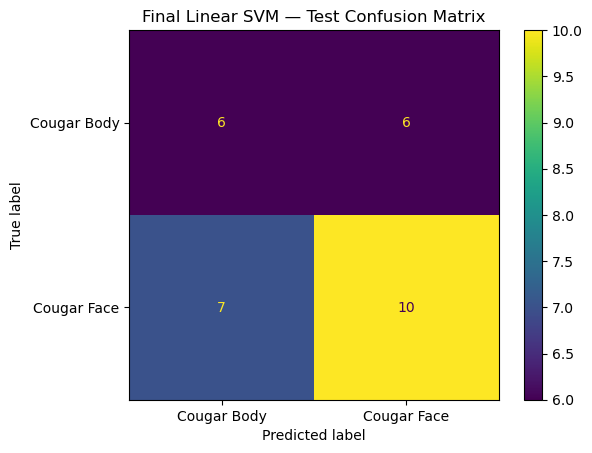

In [15]:
# ============================================================
# FINAL TEST CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(

    y_final_test,
    final_test_pred,

    labels=[
        BODY_LABEL,
        FACE_LABEL
    ]
)


print("=" * 70)
print("FINAL TEST CONFUSION MATRIX")
print("=" * 70)

print(
    "Rows    = Actual class"
)

print(
    "Columns = Predicted class"
)

print()

print(
    "                 Pred Body   Pred Face"
)

print(
    f"Actual Body      "
    f"{final_cm[0, 0]:>9d}   "
    f"{final_cm[0, 1]:>9d}"
)

print(
    f"Actual Face      "
    f"{final_cm[1, 0]:>9d}   "
    f"{final_cm[1, 1]:>9d}"
)


# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(

    confusion_matrix=final_cm,

    display_labels=[
        "Cougar Body",
        "Cougar Face"
    ]
)


disp.plot(
    values_format="d"
)

plt.title(
    "Final Linear SVM — Test Confusion Matrix"
)

plt.show()

### Class specific diagnostics

In [18]:
# ============================================================
# CLASS-SPECIFIC PERFORMANCE
# ============================================================

final_balanced_accuracy = (
    balanced_accuracy_score(
        y_final_test,
        final_test_pred
    )
)


print("=" * 70)
print("CLASS-SPECIFIC TEST PERFORMANCE")
print("=" * 70)

print(
    f"Balanced accuracy: "
    f"{final_balanced_accuracy:.4f}"
)

print()

print(
    classification_report(
        y_final_test,
        final_test_pred,

        labels=[
            BODY_LABEL,
            FACE_LABEL
        ],

        target_names=[
            "Cougar Body",
            "Cougar Face"
        ],

        digits=4,

        zero_division=0
    )
)

CLASS-SPECIFIC TEST PERFORMANCE
Balanced accuracy: 0.5441

              precision    recall  f1-score   support

 Cougar Body     0.4615    0.5000    0.4800        12
 Cougar Face     0.6250    0.5882    0.6061        17

    accuracy                         0.5517        29
   macro avg     0.5433    0.5441    0.5430        29
weighted avg     0.5574    0.5517    0.5539        29



### Save every test prediction for the image analysis

In [17]:
# ============================================================
# STORE TEST PREDICTIONS FOR QUALITATIVE ANALYSIS
# ============================================================

final_test_scores = (
    final_linear_svm.decision_function(
        X_final_test
    )
)


def label_to_name(label):

    if label == BODY_LABEL:
        return "Cougar Body"

    if label == FACE_LABEL:
        return "Cougar Face"

    return "Unknown"


final_predictions_df = pd.DataFrame({

    "Image Path":
        paths_final_test,

    "True Label":
        y_final_test,

    "True Class":
        [
            label_to_name(label)
            for label in y_final_test
        ],

    "Predicted Label":
        final_test_pred,

    "Predicted Class":
        [
            label_to_name(label)
            for label in final_test_pred
        ],

    "Decision Score":
        final_test_scores,

    "Correct":
        (
            y_final_test
            == final_test_pred
        )
})


# Distance-like confidence proxy:
# smaller absolute decision score means closer
# to the linear decision boundary.
final_predictions_df[
    "Abs Decision Score"
] = np.abs(
    final_predictions_df[
        "Decision Score"
    ]
)


final_predictions_df

,Image Path,True Label,True Class,Predicted Label,Predicted Class,Decision Score,Correct,Abs Decision Score
0,cougar_body\image_0008.jpg,-1,Cougar Body,1,Cougar Face,0.087797,False,0.087797
1,cougar_face\image_0068.jpg,1,Cougar Face,1,Cougar Face,0.822565,True,0.822565
2,cougar_face\image_0036.jpg,1,Cougar Face,1,Cougar Face,0.434864,True,0.434864
3,cougar_face\image_0047.jpg,1,Cougar Face,1,Cougar Face,1.121083,True,1.121083
4,cougar_body\image_0029.jpg,-1,Cougar Body,-1,Cougar Body,-0.111299,True,0.111299
5,cougar_face\image_0035.jpg,1,Cougar Face,1,Cougar Face,0.657804,True,0.657804
6,cougar_body\image_0043.jpg,-1,Cougar Body,-1,Cougar Body,-0.832198,True,0.832198
7,cougar_body\image_0023.jpg,-1,Cougar Body,-1,Cougar Body,-0.201286,True,0.201286
8,cougar_body\image_0021.jpg,-1,Cougar Body,1,Cougar Face,0.060254,False,0.060254
9,cougar_body\image_0047.jpg,-1,Cougar Body,-1,Cougar Body,-0.040443,True,0.040443


In [18]:
# ============================================================
# LIST FINAL TEST IMAGES BY PREDICTION OUTCOME
# ============================================================

# Add just the filename, e.g. "image_023.jpg"
final_predictions_df["Filename"] = (
    final_predictions_df["Image Path"]
    .apply(os.path.basename)
)


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def print_image_group(title, df):

    print("\n" + "=" * 85)
    print(title)
    print("=" * 85)

    if len(df) == 0:
        print("No images in this category.")
        return

    for _, row in df.iterrows():

        print(
            f"{row['Filename']:<35} "
            f"| True: {row['True Class']:<12} "
            f"| Pred: {row['Predicted Class']:<12} "
            f"| Score: {row['Decision Score']:+.4f} "
            f"| |Score|: {row['Abs Decision Score']:.4f}"
        )


# ============================================================
# 1. CORRECT BODY
# ============================================================

correct_body = (
    final_predictions_df[
        (final_predictions_df["True Label"] == BODY_LABEL)
        &
        (final_predictions_df["Predicted Label"] == BODY_LABEL)
    ]
    .sort_values(
        "Abs Decision Score",
        ascending=False
    )
)


# ============================================================
# 2. CORRECT FACE
# ============================================================

correct_face = (
    final_predictions_df[
        (final_predictions_df["True Label"] == FACE_LABEL)
        &
        (final_predictions_df["Predicted Label"] == FACE_LABEL)
    ]
    .sort_values(
        "Abs Decision Score",
        ascending=False
    )
)


# ============================================================
# 3. BODY INCORRECTLY PREDICTED AS FACE
# ============================================================

body_as_face = (
    final_predictions_df[
        (final_predictions_df["True Label"] == BODY_LABEL)
        &
        (final_predictions_df["Predicted Label"] == FACE_LABEL)
    ]
    .sort_values(
        "Abs Decision Score",
        ascending=False
    )
)


# ============================================================
# 4. FACE INCORRECTLY PREDICTED AS BODY
# ============================================================

face_as_body = (
    final_predictions_df[
        (final_predictions_df["True Label"] == FACE_LABEL)
        &
        (final_predictions_df["Predicted Label"] == BODY_LABEL)
    ]
    .sort_values(
        "Abs Decision Score",
        ascending=False
    )
)


# ============================================================
# PRINT EVERYTHING
# ============================================================

print_image_group(
    "CORRECT: COUGAR BODY",
    correct_body
)

print_image_group(
    "CORRECT: COUGAR FACE",
    correct_face
)

print_image_group(
    "ERROR: COUGAR BODY PREDICTED AS COUGAR FACE",
    body_as_face
)

print_image_group(
    "ERROR: COUGAR FACE PREDICTED AS COUGAR BODY",
    face_as_body
)


CORRECT: COUGAR BODY
image_0015.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -1.2100 | |Score|: 1.2100
image_0043.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -0.8322 | |Score|: 0.8322
image_0039.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -0.7721 | |Score|: 0.7721
image_0023.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -0.2013 | |Score|: 0.2013
image_0029.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -0.1113 | |Score|: 0.1113
image_0047.jpg                      | True: Cougar Body  | Pred: Cougar Body  | Score: -0.0404 | |Score|: 0.0404

CORRECT: COUGAR FACE
image_0020.jpg                      | True: Cougar Face  | Pred: Cougar Face  | Score: +1.7543 | |Score|: 1.7543
image_0069.jpg                      | True: Cougar Face  | Pred: Cougar Face  | Score: +1.2841 | |Score|: 1.2841
image_0047.jpg                      | True: Cougar F

In [19]:
# ============================================================
# SHORTLIST REPRESENTATIVE IMAGES TO INSPECT MANUALLY
# ============================================================

def get_representatives(df, category):

    if len(df) == 0:
        return []

    most_confident = df.iloc[0]

    closest_boundary = (
        df.sort_values(
            "Abs Decision Score",
            ascending=True
        )
        .iloc[0]
    )

    return [
        (
            category,
            "Most confident",
            most_confident
        ),
        (
            category,
            "Closest to boundary",
            closest_boundary
        )
    ]


representatives = []

representatives += get_representatives(
    correct_body,
    "Correct Body"
)

representatives += get_representatives(
    correct_face,
    "Correct Face"
)

representatives += get_representatives(
    body_as_face,
    "Body -> Face Error"
)

representatives += get_representatives(
    face_as_body,
    "Face -> Body Error"
)


print("\n" + "=" * 95)
print("RECOMMENDED IMAGES TO INSPECT")
print("=" * 95)


for category, example_type, row in representatives:

    print(
        f"\n{category} — {example_type}"
    )

    print(
        f"Filename: {row['Filename']}"
    )

    print(
        f"True class: {row['True Class']}"
    )

    print(
        f"Predicted class: {row['Predicted Class']}"
    )

    print(
        f"Decision score: {row['Decision Score']:+.4f}"
    )


RECOMMENDED IMAGES TO INSPECT

Correct Body — Most confident
Filename: image_0015.jpg
True class: Cougar Body
Predicted class: Cougar Body
Decision score: -1.2100

Correct Body — Closest to boundary
Filename: image_0047.jpg
True class: Cougar Body
Predicted class: Cougar Body
Decision score: -0.0404

Correct Face — Most confident
Filename: image_0020.jpg
True class: Cougar Face
Predicted class: Cougar Face
Decision score: +1.7543

Correct Face — Closest to boundary
Filename: image_0044.jpg
True class: Cougar Face
Predicted class: Cougar Face
Decision score: +0.0908

Body -> Face Error — Most confident
Filename: image_0019.jpg
True class: Cougar Body
Predicted class: Cougar Face
Decision score: +0.9291

Body -> Face Error — Closest to boundary
Filename: image_0038.jpg
True class: Cougar Body
Predicted class: Cougar Face
Decision score: +0.0324

Face -> Body Error — Most confident
Filename: image_0053.jpg
True class: Cougar Face
Predicted class: Cougar Body
Decision score: -0.8082

Face

# PART 2: linear vs Kernel SVM

### 4 kernels tested:
1. Linear kernel
2. polynomial kernel
3. RBF kernel
4. sigmoid kernel

### Initial settings

In [89]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# --------------------------------------------------
# Initial settings for kernel comparison
# --------------------------------------------------

# Keep C constant so that Part 2a primarily compares
# the effect of changing the kernel.
C_INITIAL = 1.0

# Suggested baseline from Part 2b:
# gamma_0 = 1 / d
feature_dimension = X_train.shape[1]
gamma_0 = 1 / feature_dimension

print("Feature dimension:", feature_dimension)
print("gamma_0:", gamma_0)


kernel_settings = {
    
    "Linear": {
        "kernel": "linear",
        "C": C_INITIAL
    },

    "Polynomial": {
        "kernel": "poly",
        "degree": 3,
        "C": C_INITIAL,
        "gamma": gamma_0
    },

    "RBF": {
        "kernel": "rbf",
        "C": C_INITIAL,
        "gamma": gamma_0
    },

    # Optional additional nonlinear kernel
    "Sigmoid": {
        "kernel": "sigmoid",
        "C": C_INITIAL,
        "gamma": gamma_0
    }
}

Feature dimension: 1024
gamma_0: 0.0009765625


### Notes:
* C = 1 for all models
* linear has no gamma
* polynomial uses degree 3
* RBF and polynomial use gamma0 = 1 / d
* sigmoid also uses the same gamma0
* feature dimension is d = 32 * 32 = 1024

### Train all kernel SVMs

In [90]:
# --------------------------------------------------
# Train SVMs with different kernels
# --------------------------------------------------

kernel_models = {}

for kernel_name, settings in kernel_settings.items():

    print(f"Training {kernel_name} SVM...")

    model = SVC(**settings)

    model.fit(X_train, y_train)

    kernel_models[kernel_name] = model

print("\nTraining complete.")

Training Linear SVM...
Training Polynomial SVM...
Training RBF SVM...
Training Sigmoid SVM...

Training complete.


### Consolidate comparison table across the different SVMs
* raw table with breakdown by class for each SV

In [91]:
# --------------------------------------------------
# Evaluate all kernel SVMs
# --------------------------------------------------

results = []

for kernel_name, model in kernel_models.items():

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    # Support vectors
    total_support_vectors = len(model.support_)

    # Support vectors from each class
    support_vectors_per_class = model.n_support_

    results.append({
        "Kernel": kernel_name,
        "Training Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Total Support Vectors": total_support_vectors,
        "SV Class -1": support_vectors_per_class[0],
        "SV Class +1": support_vectors_per_class[1]
    })


results_df = pd.DataFrame(results)

results_df

,Kernel,Training Accuracy,Test Accuracy,Total Support Vectors,SV Class -1,SV Class +1
0,Linear,1.000000,0.620690,70,29,41
1,Polynomial,0.793103,0.586207,79,35,44
2,RBF,0.896552,0.551724,82,35,47
3,Sigmoid,0.678161,0.551724,73,34,39


### Table of training and test accuracy across kernels only

In [92]:
# --------------------------------------------------
# Formatted comparison table
# --------------------------------------------------

display_results = results_df.copy()

display_results["Training Accuracy"] = (
    display_results["Training Accuracy"] * 100
).round(2)

display_results["Test Accuracy"] = (
    display_results["Test Accuracy"] * 100
).round(2)

display_results = display_results.rename(columns={
    "Training Accuracy": "Training Accuracy (%)",
    "Test Accuracy": "Test Accuracy (%)"
})

display_results

,Kernel,Training Accuracy (%),Test Accuracy (%),Total Support Vectors,SV Class -1,SV Class +1
0,Linear,100.00,62.07,70,29,41
1,Polynomial,79.31,58.62,79,35,44
2,RBF,89.66,55.17,82,35,47
3,Sigmoid,67.82,55.17,73,34,39


### Confusion matrix for each kernel

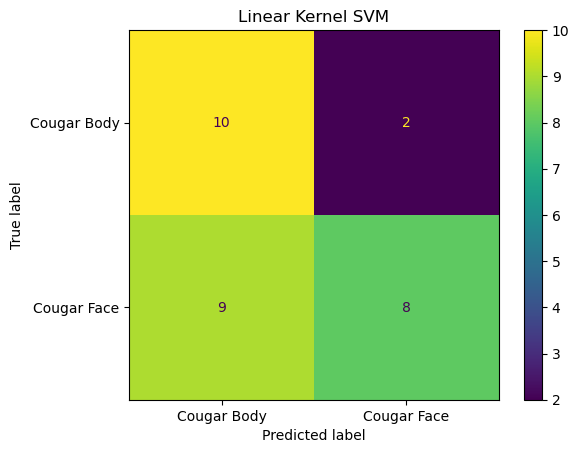

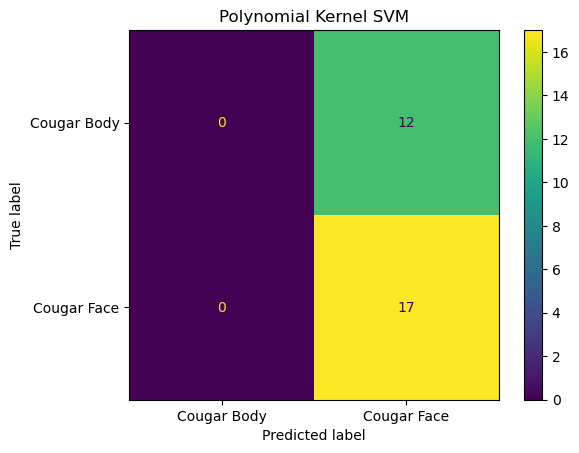

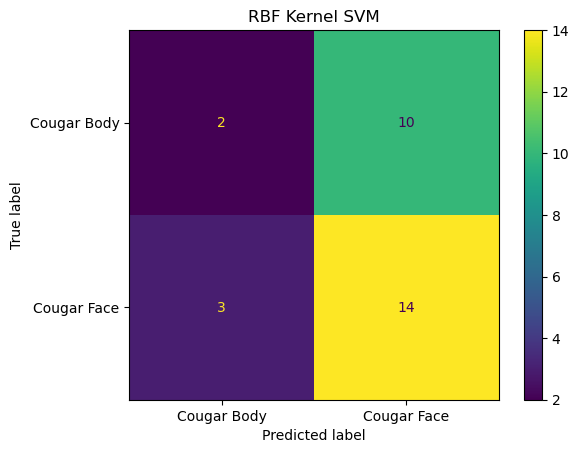

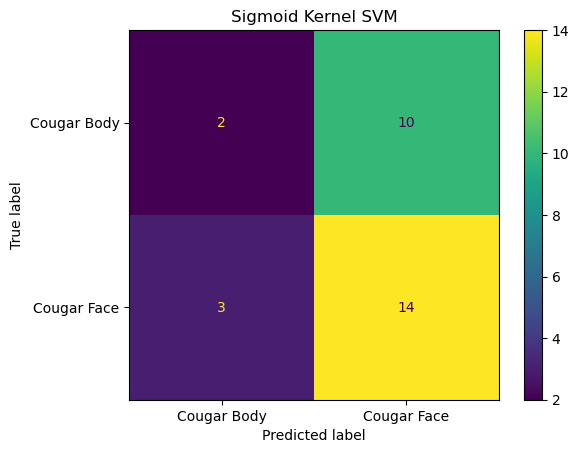

In [93]:
# --------------------------------------------------
# Confusion matrices
# --------------------------------------------------

for kernel_name, model in kernel_models.items():

    test_predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        test_predictions,
        labels=[-1, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Cougar Body", "Cougar Face"]
    )

    disp.plot()

    plt.title(f"{kernel_name} Kernel SVM")
    plt.show()

### Accuracy comparison plot

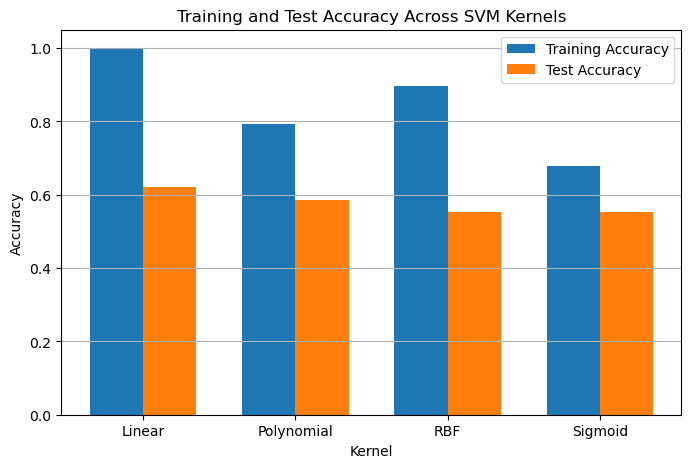

In [94]:
# --------------------------------------------------
# Plot training vs test accuracy by kernel
# --------------------------------------------------

x = np.arange(len(results_df))

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    results_df["Training Accuracy"],
    width,
    label="Training Accuracy"
)

plt.bar(
    x + width / 2,
    results_df["Test Accuracy"],
    width,
    label="Test Accuracy"
)

plt.xticks(
    x,
    results_df["Kernel"]
)

plt.ylabel("Accuracy")
plt.xlabel("Kernel")

plt.ylim(0, 1.05)

plt.title("Training and Test Accuracy Across SVM Kernels")

plt.legend()
plt.grid(axis="y")

plt.show()